In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans", "Liberation Sans"],
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42
})

import seaborn as sns

from utils.misc import bootstrapped_mean_and_ci

In [2]:
with open(f"/home/woody/iwi5/iwi5368h/evaluations/pfa_evals_0.1B/layers-run-gumbel.json", 'r') as f:
    layers_data = json.load(f)

results = defaultdict(list)
for data in layers_data:
    results[data['layer']].append({'seed': data['seed'],
                                    'stats': data['statistics'],})
results

defaultdict(list,
            {3: [{'seed': 42,
               'stats': {'next_token_losses': {'0': {'mean': 1.1514674425125122,
                  'median': 0.39453125,
                  'std': 1.5002167224884033,
                  'num': 308993,
                  'std_err': 0.002698855707421899},
                 '1': {'mean': 1.6429656744003296,
                  'median': 1.265625,
                  'std': 1.381099820137024,
                  'num': 321704,
                  'std_err': 0.0024349880404770374},
                 '2': {'mean': 2.3509457111358643,
                  'median': 2.375,
                  'std': 1.110862374305725,
                  'num': 298099,
                  'std_err': 0.002034604549407959},
                 '3': {'mean': 2.225085496902466,
                  'median': 2.28125,
                  'std': 1.2461429834365845,
                  'num': 303573,
                  'std_err': 0.002261706627905369},
                 '4': {'mean': 2.9695398807525635,

In [3]:
statistics = {}
for layer, full_data in results.items():
    num_seeds = len(full_data)
    loss_statistics = {}
    for stats_per_seed in full_data:
        for loss, loss_vals in stats_per_seed['stats'].items():
            level_statistics = {}
            for level, level_vals in loss_vals.items():
                values = np.array([d['stats'][loss][level]['mean'] for d in full_data])
                mean, lower_ci, upper_ci = bootstrapped_mean_and_ci(values, num_samples=1000)
                level_statistics[int(level)] = {'mean': mean,'lower_ci': lower_ci,'upper_ci': upper_ci}
            loss_statistics[loss] = level_statistics
    statistics[layer] = loss_statistics

In [14]:
def plot_many_layers(statistics, loss_to_plot, level_map, labels):
    levels = sorted(level_map.keys())
    cmap = plt.get_cmap('viridis', len(levels))
    colors = {level_map[lvl]: cmap(i) for i, lvl in enumerate(levels)}
    
    sorted_layer_keys = sorted(statistics.keys(), key=lambda x: int(x) if str(x).isdigit() else x)
    layers_numeric = np.array([int(l) for l in sorted_layer_keys])
    
    markers = ['o', 's', '^', 'D', 'v', 'p']
    line_styles = ['-', '--', '-.', ':', '-', '--']
    
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_facecolor('#fdf5e6')

    for level in levels:
        label_name = level_map[level]
        color = colors[label_name]
        
        means, lower_cis, upper_cis = [], [], []
        
        for layer in sorted_layer_keys:
            data = statistics[layer].get(loss_to_plot, {}).get(level)
            # if data:
            means.append(data['mean'])
            lower_cis.append(data['lower_ci'])
            upper_cis.append(data['upper_ci'])
            # else:
            #     means.append(np.nan)
            #     lower_cis.append(np.nan)
            #     upper_cis.append(np.nan)
        means = np.array(means)
        lower_cis = np.array(lower_cis)
        upper_cis = np.array(upper_cis)
        ax.fill_between(layers_numeric, lower_cis, upper_cis, alpha=0.2, color=color, edgecolor='none')
        ax.plot(layers_numeric, means, color=color, linewidth=2, label=label_name)
        ax.scatter(layers_numeric, means, color=color, s=25, zorder=3)
    ax.set_xlabel(labels[0])
    ax.set_ylabel(labels[1])

    ax.legend(frameon=True, loc='best', fancybox=False, edgecolor='black')
    plt.tight_layout()
    sns.despine(ax=ax) 
    ax.grid(True, which="both", ls='-', alpha=0.5)
    plt.savefig(f'results/{labels[1]}vs{labels[0]}_plot-gumbel-0.1B.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

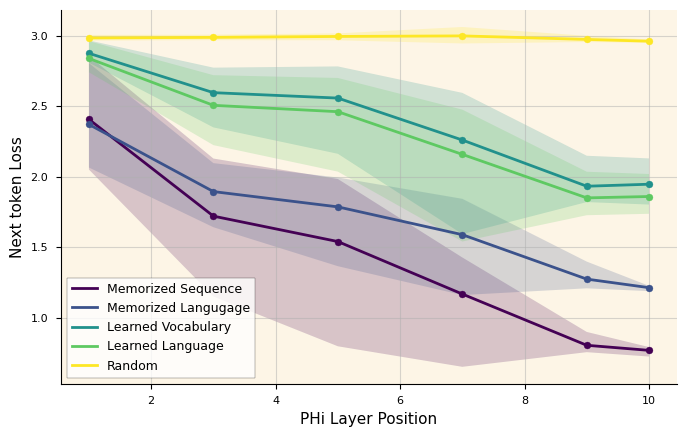

In [19]:
loss_to_plot = 'next_token_losses'
level_map = {0: 'Memorized Sequence', 1: 'Memorized Langugage', 2: 'Learned Vocabulary', 3: 'Learned Language', 4: 'Random'}
labels = [r'PHi Layer Position', r'Next token Loss']
plot_many_layers(statistics, loss_to_plot, level_map, labels)

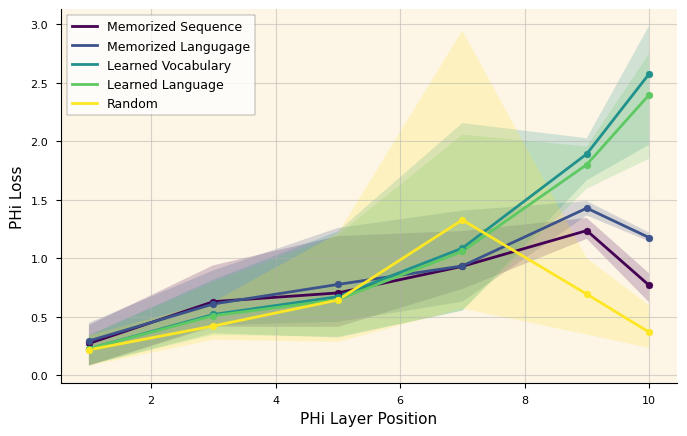

In [20]:
loss_to_plot = 'phi_losses0'
labels = [r'PHi Layer Position', r'PHi Loss']
plot_many_layers(statistics, loss_to_plot, level_map, labels)

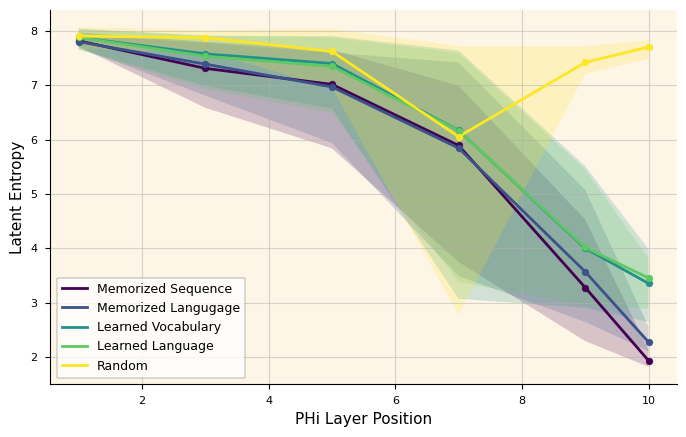

In [21]:
loss_to_plot = 'latent_entropy0'
labels = [r'PHi Layer Position', r'Latent Entropy']
plot_many_layers(statistics, loss_to_plot, level_map, labels)

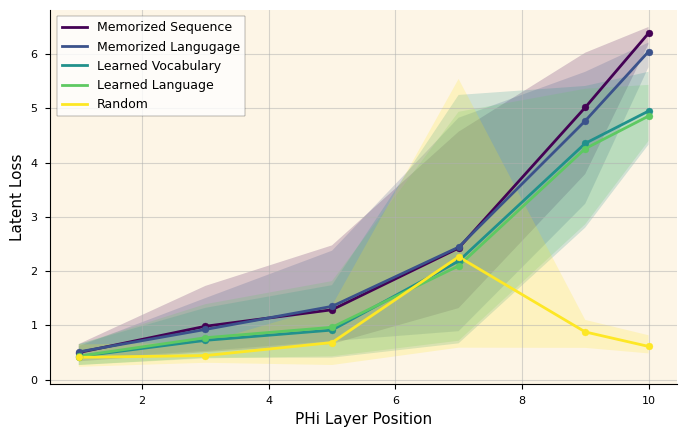

In [22]:
loss_to_plot = 'latent_losses0'
labels = [r'PHi Layer Position', r'Latent Loss']
plot_many_layers(statistics, loss_to_plot, level_map, labels)